Total Bayes Classification:
1. Estimate the parameters of classes with MLE; $\hat \mu_i$, $\hat \Sigma_i$. 
2. Use discriminant function to express the posterior probability. 
3. Compare to get decision. 

(100, 2)
[0.74908024 1.90142861] (2,)


/var/folders/q1/nxf4tks52ms9xvctj_k1b9fr0000gn/T/ipykernel_90956/3136337094.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i,j] = discriminant(point, mu_A, cov_A, p_wA) - discriminant(point, muB, cov_B, p_wB)


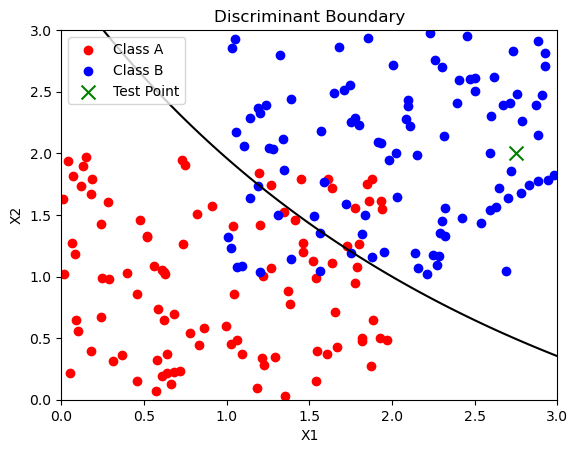

'B'

In [ ]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt

random.seed(42)
#generate two labeled class data, A and B
n_A = 100
A = np.random.uniform(low=0, high=2, size=(n_A, 2))

n_B = 100
B = np.random.uniform(low=1, high=3, size=(n_B, 2))

print(A.shape)
def para_compute(X):
    n, d = X.shape
    mu = np.mean(X, axis=0)
    X_mu = X - mu
    cov = (X_mu.T @ X_mu) / n  
    return mu, cov

print(A[0],A[0].shape)
mu_A,cov_A=para_compute(A)
muB,cov_B=para_compute(B)

p_wA=p_wB=0.5
def discriminant(x,mu,cov,p_w):
    d=x.shape[0]
    cov_inv=np.linalg.inv(cov)
    g=-0.5*np.dot(np.dot((x-mu).reshape(1,d),cov_inv),(x-mu).reshape(d,1))-0.5*np.log(np.linalg.det(cov))+np.log(p_w)
    return g

x = np.linspace(0, 3, 500)
y = np.linspace(0, 3, 500)
X_grid, Y_grid = np.meshgrid(x, y)

Z = np.zeros_like(X_grid)
for i in range(X_grid.shape[0]):
    for j in range(X_grid.shape[1]):
        point = np.array([X_grid[i,j], Y_grid[i,j]])
        Z[i,j] = discriminant(point, mu_A, cov_A, p_wA) - discriminant(point, muB, cov_B, p_wB)

test=np.array([2.75,2.0])

plt.contour(X_grid, Y_grid, Z, levels=[0], colors='black')
plt.scatter(A[:,0], A[:,1], color='red', label='Class A')
plt.scatter(B[:,0], B[:,1], color='blue', label='Class B')
plt.scatter(test[0], test[1], color='green', marker='x', s=100, label='Test Point')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.title('Discriminant Boundary')
plt.show()

g_A=discriminant(test, mu_A, cov_A, p_wA)
g_B=discriminant(test, muB, cov_B, p_wB)
print("A") if g_A>=g_B else "B"


Given the exam pass consequence: 
![Exam Pass Data](Images/exam_pass_data.png)